Modificaremos el modelo DP con competencia para agregar el factor de carga ambiental, la cual limita el crecimiento máximo que pueden tener las presas, es decir tiende a equilibrarse y acotarse. En este caso solo agregamos el termino de iota que representa dicha carga ambiental en el sistema, obteniendo la siguiente ED: [ED DP con competencia y carga ambiental](resources\ED_DPMC.PNG). 

Nótese que con iota=0 recuperamos el modelo de DP con competencia.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

#Constantes del modelo depredador-presa
nu = 1 #Tasa de crecimiento de presas
mu = 0.02 #Tasa de caza de presas por depredadores 1
kappa = 0.018 #Tasa de caza de presas por depredadores 2
iota = 0.001 #Carga ambiental de presas

delta = 0.4 #Tasa de mortalidad de depredadores 1
alpha = 0.01 #Tasa de reproducción de depredadores 1 por consumo de presas

Delta = 0.36 #Tasa de mortalidad de depredadores 2
beta = 0.01 #Tasa de reproducción de depredadores 2 por consumo de presas

P0 = 120 #Población inicial de presas
D0 = 10 #Pobalción inicial de depredadores 1
C0 = 10 #Población inicial de depredadores 2
dias = 200 #Tiempo de simulación

Calculamos el cambio en el tiempo de cada población.

In [3]:
#Sistema de ED del modelo DP con competencia
def DP(P, D, C, nu, mu, kappa, iota, delta, alpha, Delta, beta):
    dP_dt = P * (nu - (mu * D + kappa * C  + iota * P))
    dD_dt = D * ((alpha * P) - delta)
    dC_dt = C * ((beta * P) - Delta)
    return dP_dt, dD_dt, dC_dt

Simulamos el sistema durante el tiempo designado.

In [4]:
#Simulación del sistema de ED DP con competencia
def simu_DP(P0, D0, C0, nu, mu, kappa, iota, delta, alpha, Delta, beta, dias):
    dt = 0.01  # Paso de tiempo
    pasos_totales = int(dias / dt)
    P = np.zeros(pasos_totales)
    D = np.zeros(pasos_totales)
    C = np.zeros(pasos_totales)
    
    P[0] = P0
    D[0] = D0
    C[0] = C0

    for t in range(1, pasos_totales):
        dP_dt, dD_dt, dC_dt = DP(P[t-1], D[t-1], C[t-1], nu, mu, kappa, iota, delta, alpha, Delta, beta)
        P[t] = P[t-1] + dP_dt * dt
        D[t] = D[t-1] + dD_dt * dt
        C[t] = C[t-1] + dC_dt * dt

        # Acotamos la población, ya que no hay poblaciones negativas
        P[t] = max(P[t], 0)
        D[t] = max(D[t], 0)
        C[t] = max(C[t], 0)

    return P, D, C

Finalmente obtenemos P, D y C como una evolución temporal continua bajo el sistema de ED del modelo DP con competencia.

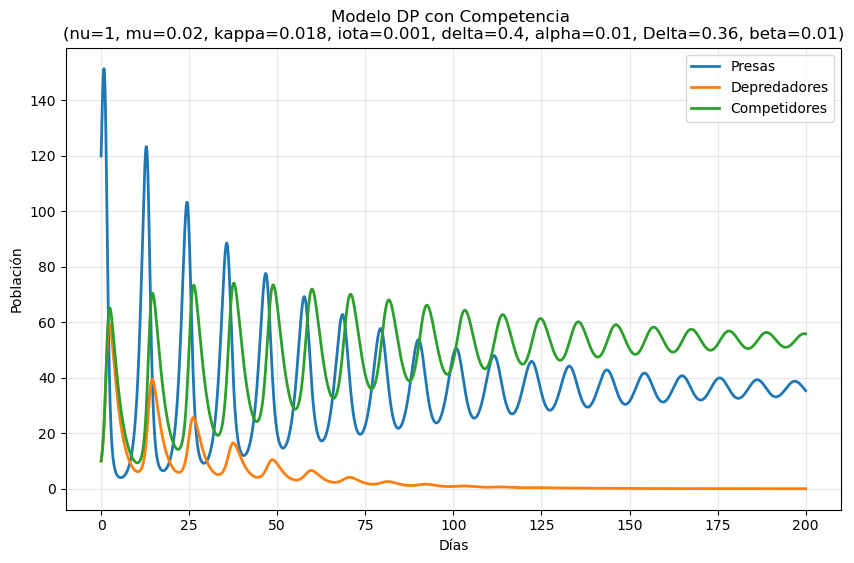

In [5]:
#Simulación
P, D, C = simu_DP(P0, D0, C0, nu, mu, kappa, iota, delta, alpha, Delta, beta, dias)

# Designamos el avance temporal ajustado a la cantidad de dias de simulación
dt = 0.01
tiempo = np.arange(0, dias, dt)

#Gráfica de resultados
plt.figure(figsize=(10,6))
plt.plot(tiempo, P, label='Presas', linewidth=2)
plt.plot(tiempo, D, label='Depredadores', linewidth=2)
plt.plot(tiempo, C, label='Competidores', linewidth=2)
plt.xlabel('Días')
plt.ylabel('Población')
plt.title('Modelo DP con Competencia \n(nu={}, mu={}, kappa={}, iota={}, delta={}, alpha={}, Delta={}, beta={})'.format(nu, mu, kappa, iota, delta, alpha, Delta, beta))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

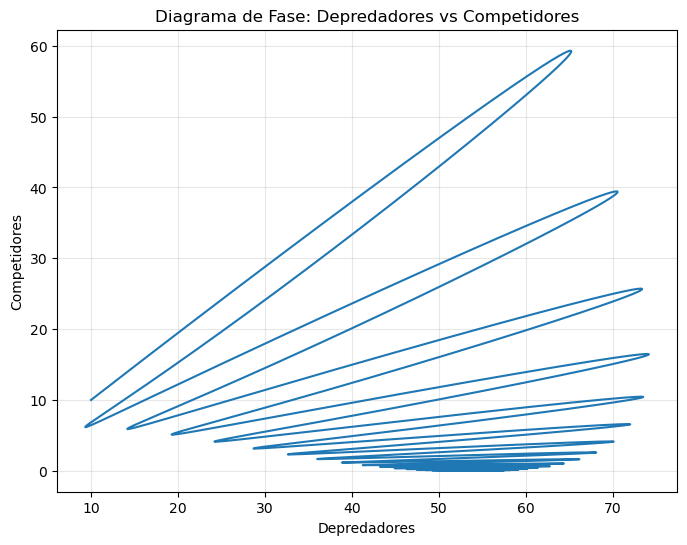

In [6]:
#Diagrama de fase
plt.figure(figsize=(8,6))
plt.plot(C, D)
plt.xlabel('Depredadores')
plt.ylabel('Competidores')
plt.title('Diagrama de Fase: Depredadores vs Competidores')
plt.grid(alpha=0.3)
plt.show()